# Lab 3 - Filtros no espaço e na frequência

Objetivo: analisar as imagens da pasta `imagens` e tentar reduzir o ruído usando filtros no domínio espacial e no domínio da frequência.

A ideia foi escolher filtros simples e comparar visualmente o resultado.

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["image.cmap"] = "gray"

salt = cv2.imread("imagens/salt_noise.png", 0)
halftone = cv2.imread("imagens/halftone.png", 0)
pieces = cv2.imread("imagens/pieces.png", 0)

imagens = {
    "salt_noise.png": salt,
    "halftone.png": halftone,
    "pieces.png": pieces,
}

for nome, img in imagens.items():
    print(nome, img.shape)

salt_noise.png (440, 455)
halftone.png (666, 1000)
pieces.png (600, 800)


In [10]:
def mostrar(titulo, lista):
    plt.figure(figsize=(15, 5))
    for i, (nome, img) in enumerate(lista, start=1):
        plt.subplot(1, len(lista), i)
        plt.imshow(img, cmap="gray")
        plt.title(nome)
        plt.axis("off")
    plt.suptitle(titulo)
    plt.show()


def espectro(img):
    f = np.fft.fft2(img)
    f = np.fft.fftshift(f)
    return np.log(1 + np.abs(f))


def passa_baixa_frequencia(img, raio):
    linhas, colunas = img.shape
    centro_linha = linhas // 2
    centro_coluna = colunas // 2

    # FFT da imagem
    f = np.fft.fft2(img)
    f_shift = np.fft.fftshift(f)

    # Máscara circular: mantém baixas frequências e corta altas frequências
    mascara = np.zeros((linhas, colunas), dtype=np.uint8)
    cv2.circle(mascara, (centro_coluna, centro_linha), raio, 1, -1)

    f_filtrado = f_shift * mascara

    # Volta para o domínio espacial
    img_volta = np.fft.ifft2(np.fft.ifftshift(f_filtrado))
    img_volta = np.abs(img_volta)
    img_volta = np.clip(img_volta, 0, 255).astype(np.uint8)

    return img_volta, mascara

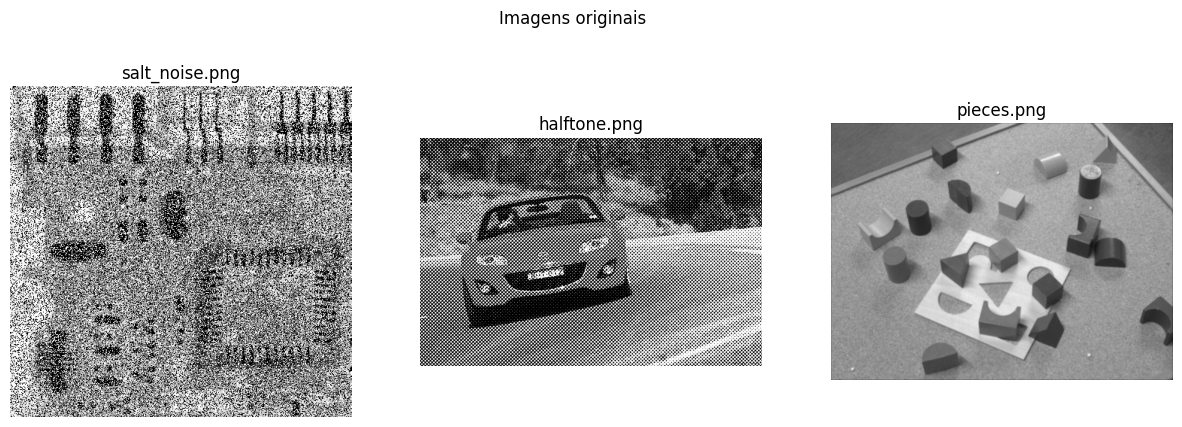

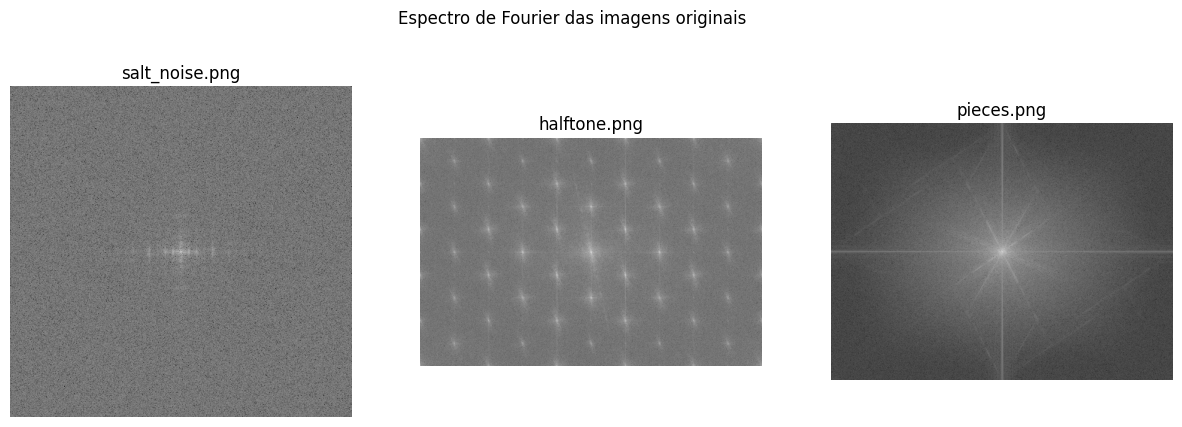

In [11]:
mostrar(
    "Imagens originais",
    [(nome, img) for nome, img in imagens.items()]
)

mostrar(
    "Espectro de Fourier das imagens originais",
    [(nome, espectro(img)) for nome, img in imagens.items()]
)

In [12]:
# salt_noise.png
# Ruído do tipo sal e pimenta: filtro de mediana costuma funcionar bem.
salt_espaco = cv2.medianBlur(salt, 5)
salt_freq, salt_mascara = passa_baixa_frequencia(salt, raio=45)

# halftone.png
# A retícula tem muitos detalhes repetidos; o Gaussiano e o passa-baixa suavizam essa repetição.
halftone_espaco = cv2.GaussianBlur(halftone, (7, 7), 1.5)
halftone_freq, halftone_mascara = passa_baixa_frequencia(halftone, raio=90)

# pieces.png
# Ruído mais suave/granulado: Gaussiano leve reduz a granulação.
pieces_espaco = cv2.GaussianBlur(pieces, (5, 5), 1)
pieces_freq, pieces_mascara = passa_baixa_frequencia(pieces, raio=70)

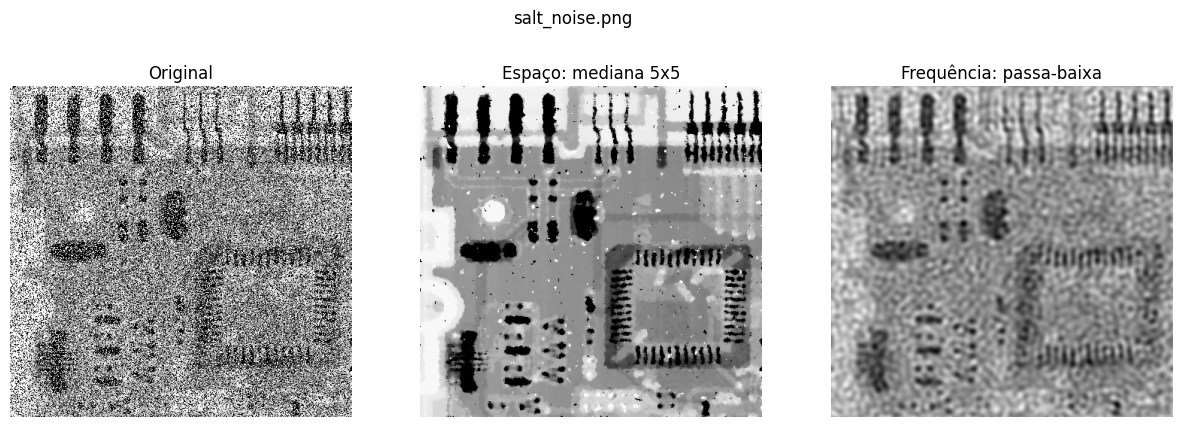

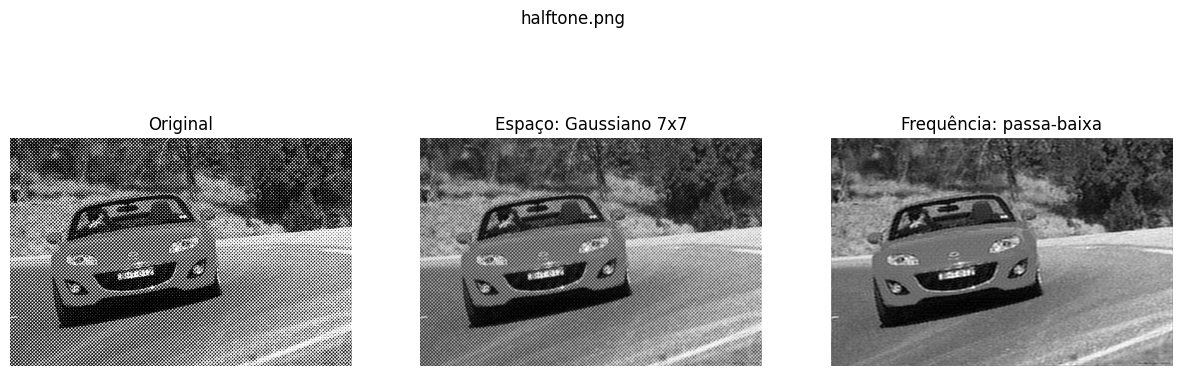

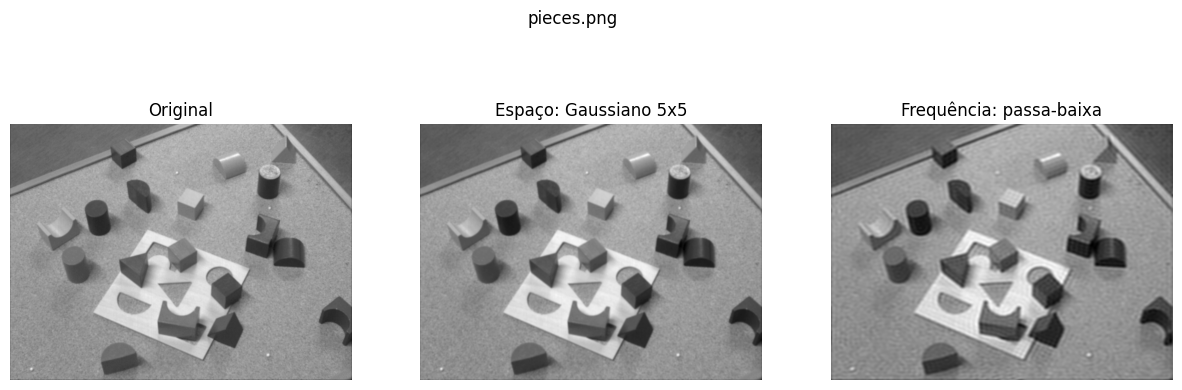

In [13]:
mostrar(
    "salt_noise.png",
    [
        ("Original", salt),
        ("Espaço: mediana 5x5", salt_espaco),
        ("Frequência: passa-baixa", salt_freq),
    ]
)

mostrar(
    "halftone.png",
    [
        ("Original", halftone),
        ("Espaço: Gaussiano 7x7", halftone_espaco),
        ("Frequência: passa-baixa", halftone_freq),
    ]
)

mostrar(
    "pieces.png",
    [
        ("Original", pieces),
        ("Espaço: Gaussiano 5x5", pieces_espaco),
        ("Frequência: passa-baixa", pieces_freq),
    ]
)

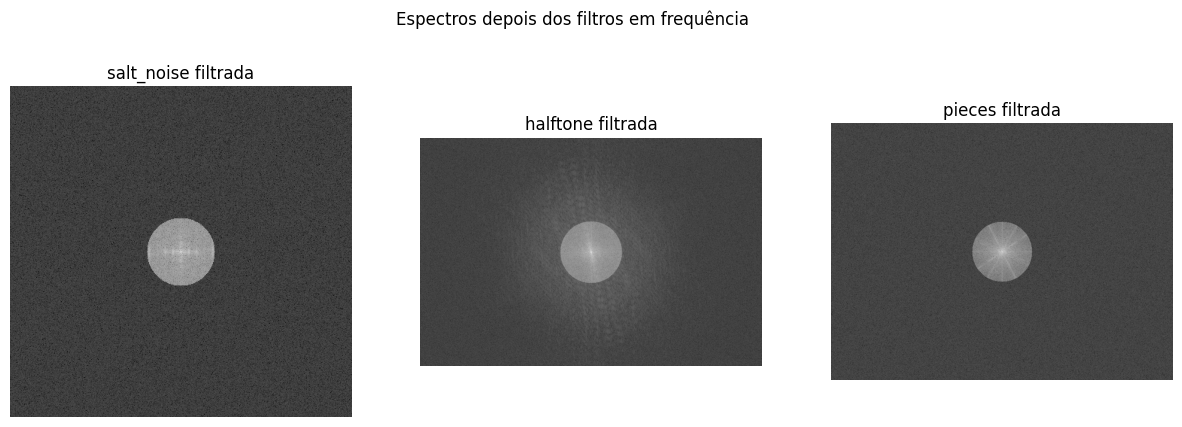

In [14]:
mostrar(
    "Espectros depois dos filtros em frequência",
    [
        ("salt_noise filtrada", espectro(salt_freq)),
        ("halftone filtrada", espectro(halftone_freq)),
        ("pieces filtrada", espectro(pieces_freq)),
    ]
)

## Explicação dos resultados

### `salt_noise.png`

Essa imagem tem muitos pontos pretos e brancos espalhados, que parecem ruído de sal e pimenta. Por isso usei a mediana no domínio espacial. Ela troca cada pixel por um valor mais representativo da vizinhança e consegue remover vários pontos isolados sem borrar tanto a imagem.

No domínio da frequência usei um passa-baixa. Ele reduz altas frequências, então também diminui parte do ruído. Porém, nesse caso, o resultado fica mais borrado, porque o ruído de sal e pimenta se mistura com detalhes reais da imagem. Para essa imagem, o filtro de mediana foi o melhor.

### `halftone.png`

A imagem tem uma textura de pontinhos repetidos, parecida com impressão de jornal. Usei Gaussiano no espaço para suavizar esses pontos e tentar formar regiões mais contínuas. Ele reduz a textura, mas também deixa as bordas menos nítidas.

Na frequência, o passa-baixa corta parte das frequências altas, onde essa repetição aparece bastante. O resultado também suaviza a retícula. O ponto negativo é parecido: se cortar demais, a imagem perde detalhes. Mesmo assim, para esse tipo de ruído repetitivo, olhar a frequência ajuda bastante a entender o problema.

### `pieces.png`

Essa imagem tem uma granulação mais leve. Usei um Gaussiano 5x5 no espaço porque ele reduz pequenas variações de intensidade e deixa a imagem mais lisa. Como o ruído não é tão forte, não precisei usar um filtro muito agressivo.

Na frequência usei novamente o passa-baixa. Ele reduz a granulação, mas também suaviza um pouco as bordas das peças. O resultado é bom quando queremos uma imagem mais limpa, mas o filtro espacial leve preservou melhor os contornos.

## Conclusão

O filtro mais adequado depende do tipo de ruído. Para sal e pimenta, a mediana foi melhor. Para a retícula da imagem `halftone`, os filtros de suavização reduzem o padrão repetido, principalmente quando olhamos o problema pela frequência. Para `pieces`, um Gaussiano leve já foi suficiente para diminuir a granulação sem perder muitos detalhes.